# Phylotrajectories.jl — usage example

This notebook walks through the **OU‑MCMC** pipeline of
`Phylotrajectories.jl` on a small simulated dataset that ships with
the package (`examples/data/simulated_clone_data.csv`).

This notebook:

 **Loads** a wide-form clonotype-by-cell-type count matrix with
   `import_count_matrix`. \
**Runs OU-MCMC** to sample a posterior over trees + OU parameters. \
**Builds a HIPSTR consensus** and inspect the diagnostic traces. \
**Plots the consensus tree** annotated with per-node posterior
   support.


## 1. Set up the environment

Activate the package, load the dependencies, and fix the random seed.

In [1]:
import Pkg
# Activate the parent package so `using Phylotrajectories` resolves to this checkout.
Pkg.activate(joinpath(@__DIR__, ".."))
# Pkg.instantiate()    # uncomment on first run

  Activating project at `~/Phylotrajectories.jl`


In [2]:
using Phylotrajectories
using MolecularEvolution
using ForwardBackward

using CSV, DataFrames
using Distributions, Statistics, StatsBase, LinearAlgebra
using Plots, Plots.PlotMeasures, ColorSchemes
using Phylo
using Random
using Printf

const NUMBER_SEED = 1234
Random.seed!(NUMBER_SEED);


[ Info: Precompiling Phylotrajectories [85c2bcf0-676d-4e10-9b42-7fb9c3e18bdd] (cache misses: include_dependency fsize change (2), wrong dep version loaded (2))
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Info: Skipping precompilation due to precompilable error. Importing Phylotrajectories [85c2bcf0-676d-4e10-9b42-7fb9c3e18bdd].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.


## 2. Output directory

All figures, tree files and clone matrices land in `examples/results/`.

In [3]:
path = joinpath(@__DIR__, "results")
isdir(path) || mkpath(path)
@info "Saving outputs under" path

┌ Info: Saving outputs under
└   path = "/home/masha/Phylotrajectories.jl/examples/results"


## 3. Read the simulated clone count matrix

The bundled `simulated_clone_data.csv` is a wide-form CSV: rows are
clonotypes, columns are cell-type subsets (`Subset1`…`Subset6`).

The single-argument form of `import_count_matrix(fname)` returns a
4-tuple `(clono_info, cluster_names, cluster_sizes, count_matrix)`.
For wide-form CSVs the metadata fields (`clono_info`, `cluster_sizes`)
are `nothing`, so we only keep the cluster names and the integer
count matrix.

In [4]:
_, cluster_names, _, count_matrix = import_count_matrix(
    joinpath(@__DIR__, "data", "simulated_clone_data.csv"),
);

In [6]:
cluster_names

6-element Vector{String}:
 "Subset2"
 "Subset5"
 "Subset6"
 "Subset1"
 "Subset3"
 "Subset4"

In [8]:
count_matrix

6×750 Matrix{Int64}:
 0  1  1  0  2  0  0  1  1  0  1  1  1  …  0  0  0  0  0  2  0  0  1  1  0  0
 0  2  0  0  1  0  0  0  0  1  0  0  3     2  0  0  0  0  0  2  0  0  0  0  1
 1  1  0  0  0  0  0  0  0  5  2  0  5     0  0  0  0  0  0  3  0  0  0  2  0
 0  0  0  0  0  0  1  0  0  0  0  0  0     0  0  0  0  1  0  0  1  0  0  0  0
 1  1  0  0  0  0  0  0  0  1  1  0  0     0  1  1  0  0  0  0  0  0  0  2  1
 0  0  0  1  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0

## 2. OU MCMC hyper-parameters & model factory

Frequencies diffuse along the tree under an Ornstein–Uhlenbeck (OU)
process — a Brownian motion with mean-reversion towards an
equilibrium. `make_ou_model` collects every knob in one place:

- `digamma_value`, `trigamma_value` — pseudo-counts added to zero
  entries before the digamma / trigamma transforms used to seed the
  leaf Gaussian likelihoods.
- `eqmu`, `eqtheta`, `v` — initial values of the OU process
  (equilibrium mean, mean-reversion strength, variance).
- `tree_warmup_cycles` — initial MCMC iterations with branch lengths
  and OU parameters frozen, so the topology can relax first.
- `burn_in`, `sample_interval`, `n_samples` — standard MCMC knobs.


In [9]:
digamma_value  = 0.5
trigamma_value = 0.5

eqmu    = 1.5
eqtheta = 0.1
v       = 1.0

start_branch_length = 0.1

function make_ou_model(;
    nni = 1,
    branchlength = 1,
    root = 1,
    models = 1,
    tree_warmup_cycles = 100,
    burn_in = 5_000,
    sample_interval = 100,
    n_samples = 100,
)
    return OUContinuousModel(
        update = OUContinuousUpdate(
            nni = nni,
            branchlength = branchlength,
            root = root,
            models = models,
            branchlength_sampler = BranchlengthSampler(Normal(0, 0.1), Normal(-1, 1)),
            root_sampler = OUGaussianStateSample(
                MvNormal(zeros(2), Diagonal([0.01, 0.01])),
                MvNormal(zeros(2), Diagonal([1.0, 0.1])),
                1e-1, 1,
            ),
            ou_eqmu_sampler  = OUEqmuSampler(Normal(0.0, 2.0), Normal(1.5, 1.0), 1.0, 0.1),
            ou_theta_sampler = OUThetaSampler(Normal(0, 0.1), Normal(-1, 1), 1.5, 1.0),
        ),
        start_branch_length = start_branch_length,
        tree_warmup_cycles  = tree_warmup_cycles,
        burn_in             = burn_in,
        sample_interval     = sample_interval,
        n_samples           = n_samples,
    )
end


make_ou_model (generic function with 1 method)

## 3. Run OU-MCMC inference

In [10]:
println("=" ^ 60)
println("Running OU MCMC inference on simulated data...")
println("=" ^ 60)

plot_init, init_tree, trees, LLs, models, root_ps, upd =
    tree_inference(
        make_ou_model(),
        cluster_names, count_matrix;
        eqmu = eqmu,
        eqtheta = eqtheta,
        v = v,
        d = digamma_value,
        g = trigamma_value,
    );


Running OU MCMC inference on simulated data...
Using random tree.
Tree-only warmup: 100 cycles with fixed branch lengths and theta=0.1
Warmup final LL: -5352.755174232737
Starting LL: -5352.755174232737
Inference

## 4. HIPSTR consensus tree

`HIPSTR` builds a maximum-credibility tree from the posterior sample. We
also retain the per-node **support** values for the credibility plot below.

In [11]:
ladderize!.(trees)
hip, node2logcred, node2support = HIPSTR(trees; getcred = true, getsupport = true)
mltpl = plot_multiple_trees(trees, hip; line_width = 1.0);

## 5. Profile sampling and MCMC trees

Standard OU-MCMC diagnostics: log-likelihood trace, equilibrium mean
acceptance ratio, mean-reversion `θ`, variance, the (1-D marginal of the)
root state distribution across samples, and the MCMC posterior cloud
overlaid on the HIPSTR tree.

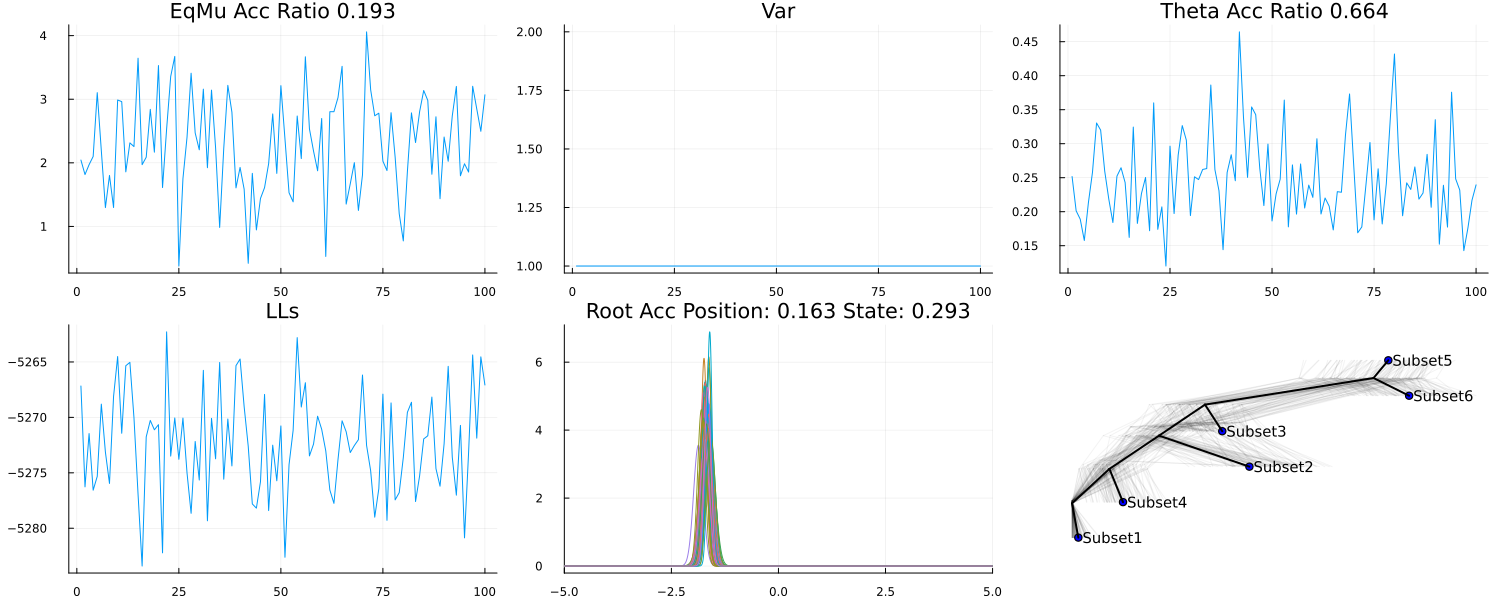

In [12]:
lls = plot(LLs, legend = :none);  title!(lls, "LLs");

means = plot([x[3] for x in models], legend = :none);
title!(means, "EqMu Acc Ratio $(round(upd.models_update.eqmu_sampler.acc_ratio[1], digits=3))");

theta = plot([x[1] for x in models], legend = :none);
title!(theta, "Theta Acc Ratio $(round(upd.models_update.theta_sampler.acc_ratio[1], digits=3))");

vars = plot([x[2] for x in models], legend = :none);
title!(vars, "Var");

plot_root = plot(xlims = (-5, 5), legend = false)
for p in root_ps
    plot!(plot_root, x -> pdf(Normal(p[1][1], p[1][2]), x))
end
title!(
    plot_root,
    "Root Acc Position: $(round(upd.root_update.acc_ratio.position[1], digits=3))" *
    " State: $(round(upd.root_update.acc_ratio.state[1], digits=3))",
);

combined_plt = plot(
    [means, vars, theta, lls, plot_root, mltpl]...;
    layout = (2, 3), size = (1500, 600),
);

hipster_tree = plot(mltpl; fontsize = 10, margins = 10mm);

savefig(combined_plt, joinpath(path, "OU_sim_$(digamma_value)_$(trigamma_value)_$(NUMBER_SEED)_theta.pdf"))
savefig(hipster_tree, joinpath(path, "OU_sim_$(digamma_value)_$(trigamma_value)_hipster_$(NUMBER_SEED)_theta.pdf"))

# Save the HIPSTR consensus as Newick
Phylo.write(
    joinpath(path, "HIPSTR_tree.newick"),
    get_phylo_tree(hip),
)

display(combined_plt)


## 6. Credibility plot for the HIPSTR tree

For each internal node we use the posterior **support** as both a colour
(red→blue, low→high) and a marker size, then annotate the value to the
right of the bubble.

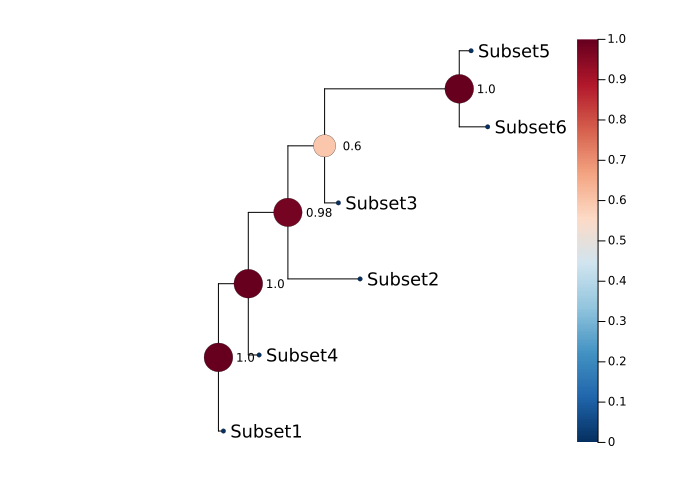

In [13]:
function max_root_distance(node, dist = 0.0)
    if isleafnode(node)
        return dist
    end
    return maximum(max_root_distance(ch, dist + ch.branchlength) for ch in node.children)
end

for n in getnodelist(hip)
    if isleafnode(n)
        n.node_data = Dict("size" => 2.5, "support_plot" => 0.0)
    else
        s = node2support[n]
        n.node_data = Dict("size" => 16 * sqrt(s), "support_plot" => s)
    end
end

phylo_tree = get_phylo_tree(hip)

max_depth  = max_root_distance(hip)
xpad_left  = 0.06 * max_depth
xpad_right = 0.28 * max_depth

pl_cred = plot(
    phylo_tree;
    showtips = true,
    tipfont = 12,
    markersize  = values_from_phylo_tree(phylo_tree, "size"),
    marker_z    = values_from_phylo_tree(phylo_tree, "support_plot"),
    markercolor = cgrad(reverse(ColorSchemes.RdBu_10.colors)),
    clims = (0.0, 1.0),
    markerstrokecolor = :black,
    markerstrokewidth = 0.25,
    linewidth = 1.0,
    xlims = (-xpad_left, max_depth + xpad_right),
    left_margin = 45mm, right_margin = 15mm,
    top_margin = 8mm,   bottom_margin = 8mm,
    colorbar = :right,
    size = (700, 500),
)

# Annotate internal-node support values
scatter_series = pl_cred.series_list[2]
xs = scatter_series[:x]
ys = scatter_series[:y]
zs = scatter_series[:marker_z]
for i in eachindex(xs)
    s = zs[i]
    if s > 0.0       # skip leaves (we set their support to 0)
        annotate!(
            pl_cred,
            xs[i] + 0.07 * max_depth, ys[i],
            text(string(round(s; digits = 3)), 8, :left, :black),
        )
    end
end

savefig(pl_cred, joinpath(path, "HIPSTR_with_support.pdf"))
display(pl_cred)
